# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Sinadjan, Joseph Daniel
- _Student No._: 2024-13266
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

Resistor drop across the network was linear for any N nodes up to N = 100,000. Overall, the implementation of matrices was made easy thanks to numpy's matrix comprehensions. I was surprised with how easy it was to manipulate matrix rows, columns, and elements using 'slices'. I a

### Other comments
- No AI was used in this probset.

---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [4]:
# code here
import matplotlib.pyplot as plt
import numpy as np


In [5]:
#matrix solver for N = 6

V = 5
V_ = 0

res_ladder = np.array([[3,-1,-1, 0,0,0],
                      [-1, 4,-1,-1,0,0],
                      [-1,-1,4,-1,-1,0],
                      [0,-1,-1,4,-1,-1],
                      [0,0,-1,-1, 4,-1],
                      [0,0, 0,-1,-1, 3]], float)

w = np.array([V, V, 0, 0, V_, V_], float)

N = len(w)

# This section is taken from gauselim from Gezerlis
# Gaussian elimination
for m in range(N):

    # Divide by the diagonal element
    div = res_ladder[m,m]
    res_ladder[m,:] /= div
    w[m] /= div

    # Now subtract from the lower rows
    for i in range(m+1,N):
        mult = res_ladder[i,m]
        res_ladder[i,:] -= mult*res_ladder[m,:]
        w[i] -= mult*w[m]

# Backsubstitution
x = np.empty(N,float)
for m in range(N-1,-1,-1):
    x[m] = w[m]
    for i in range(m+1,N):
        x[m] -= res_ladder[m,i]*x[i]

print(x)

[3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


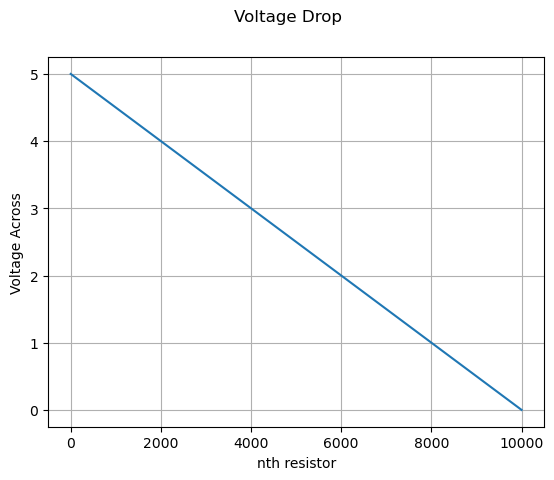

In [19]:
#matrix_solver for N = 10,000

def banded(Aa,va,up,down):

    # Copy the inputs and determine the size of the system
    A = np.copy(Aa)
    v = np.copy(va)
    N = len(v)

    # Gaussian elimination
    for m in range(N):

        # Normalization factor
        div = A[up,m]

        # Update the vector first
        v[m] /= div
        for k in range(1,down+1):
            if m+k<N:
                v[m+k] -= A[up+k,m]*v[m]

        # Now normalize the pivot row of A and subtract from lower ones
        for i in range(up):
            j = m + up - i
            if j<N:
                A[i,j] /= div
                for k in range(1,down+1):
                    A[i+k,j] -= A[up+k,m]*A[i,j]

    # Backsubstitution
    for m in range(N-2,-1,-1):
        for i in range(up):
            j = m + up - i
            if j<N:
                v[m] -= A[i,j]*v[j]

    return v

A = np.zeros((10000,10000))

for m in range(10000):
    A[m,m] = 4
    A[m-1,m] = -1
    A[m-2,m] = -1
    A[m, m-1] = -1
    A[m, m-2] = -1

A[9999,0] = 0
A[9998,0] = 0
A[9999,1] = 0
A[0,9999] = 0
A[0,9998] = 0
A[1,9999] = 0
A[0,0] = 3
A[9999,9999] = 3

B = np.zeros((5,10000))

for m in range(10000):
    B[0,m] = -1
    B[1,m] = -1
    B[2,m] = 4
    B[3,m] = -1
    B[4,m] = -1
B[2,0]=3
B[2,9999]=3

V = 5
V_ = 0

v = np.zeros(10000)
v[0]= V
v[1]= V
v[9998] = V_
v[9999] = V_


z = banded(B, v, 2, 2)


fig, ax1 = plt.subplots()
fig.suptitle("Voltage Drop")

ax1.plot(np.linspace(0,10000, num=10000), banded(B,v,2,2))
ax1.set_xlabel("nth resistor")
ax1.set_ylabel("Voltage Across")
ax1.grid()

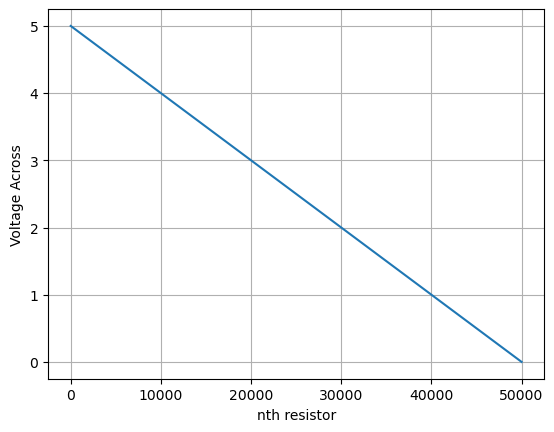

In [14]:
# for n = 50,000
B_a = np.zeros((5,50000))

for m in range(50000):
    B_a[0,m] = -1
    B_a[1,m] = -1
    B_a[2,m] = 4
    B_a[3,m] = -1
    B_a[4,m] = -1
B_a[2,0]=3
B_a[2,49999]=3

v0 = np.zeros(50000)
v0[0]= V
v0[1]= V
v0[49998] = V_
v0[49999] = V_



a0 = banded(B_a, v0, 2, 2)

fig, ax2 = plt.subplots()
fig.suptitle("Voltage Drop")

ax2.plot(np.linspace(0,50000, num=50000), a0)
ax2.set_xlabel("nth resistor")
ax2.set_ylabel("Voltage Across")
ax2.grid()

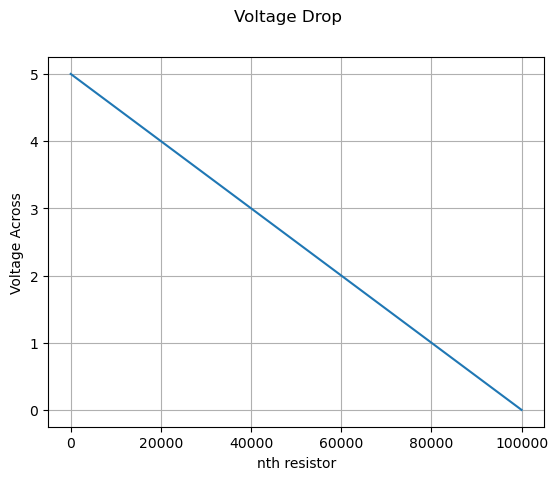

In [18]:
# for n = 100000
B_b = np.zeros((5,100000))

for m in range(100000):
    B_b[0,m] = -1
    B_b[1,m] = -1
    B_b[2,m] = 4
    B_b[3,m] = -1
    B_b[4,m] = -1
B_b[2,0]=3
B_b[2,99999]=3

v1 = np.zeros(100000)
v1[0]= V
v1[1]= V
v1[99998] = V_
v1[99999] = V_



a1 = banded(B_b, v1, 2, 2)

fig, ax3 = plt.subplots()
fig.suptitle("Voltage Drop")

ax3.plot(np.linspace(0,100000, num=100000), a1)
ax3.set_xlabel("nth resistor")
ax3.set_ylabel("Voltage Across")
ax3.grid()

#### Problem 1 code summary

We implemented the code using np matrix comprehension and used np.zeros() to generate large nxn or nx1 arrays. The actual linear system solver was imported from Gezerlis.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [6]:
import samplePackage as sP

In [7]:
sP.createZerosArray(4,5)

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])